# Whole-file LM-CC results

Complexity metrics computed on the **whole** pre-patch target file, correlated with the single-model
Agentless Claude-3.5-Sonnet `resolved` label. The all-agents resolution-rate analysis (incl. Table 1)
follows in the second half.

In [ ]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent)) 

from src.config import PATHS
import pandas as pd

metrics_df = pd.read_parquet(PATHS.WHOLE_FILE_RESULT_DATASET)
labeled_df = pd.read_parquet(PATHS.LABELED_DATASET)

merged = metrics_df.merge(
    labeled_df[["instance_id", "resolved"]],
    on="instance_id",
    how="left",
)

clean = merged[
    merged["parsable"] 
    & merged["lm_cc_score"].notna() 
    & merged["resolved"].notna()
].copy()

print(f"Total: {len(merged)}")
print(f"Usable: {len(clean)}")
print(f"Resolve rate: {clean['resolved'].mean():.1%}")

## LM-CC distribution

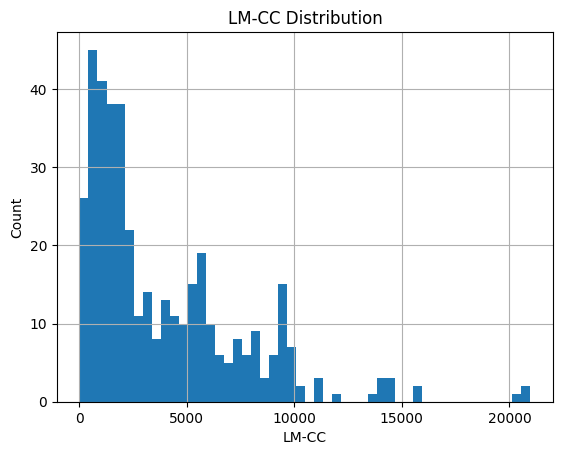

In [2]:
import matplotlib.pyplot as plt

clean["lm_cc_score"].describe()

clean["lm_cc_score"].hist(bins=50)
plt.xlabel("LM-CC")
plt.ylabel("Count")
plt.title("LM-CC Distribution")
plt.show()

## Correlation table — metrics vs. `resolved`

Zero-order and LOC-controlled (sample + subgroup) Spearman correlations, mirroring the paper's Table 2.

In [3]:
from src.correlation import full_correlation_table

metrics_to_compare = [
    "cc_avg",
    "cc_max", 
    "cc_sum",
    "halstead_volume",
    "halstead_difficulty",
    "halstead_effort",
    "loc",
    "lloc",
    "nesting_max",
    "token_count",
    "function_count",
    "n_branches",
    
    "lm_cc_max_comp",      
    "lm_cc_avg_comp",      
    "lm_cc_total_comp",    
    "lm_cc_max_branch",   
    "lm_cc_avg_branch",    
    "lm_cc_total_branch",  
    
    "lm_cc_score",
]
available_metrics = [m for m in metrics_to_compare if m in clean.columns]

result_table = full_correlation_table(clean, available_metrics)
print("=== Full Correlation Table (vs. resolved) ===")
print(result_table.to_string(index=False))

=== Full Correlation Table (vs. resolved) ===
             metric      sample_zero sample_partial_loc          subgroup_zero   subgroup_partial_loc
             cc_avg -0.010 (p=0.843)   +0.004 (p=0.939) -0.333 (p=0.347, n=10) -0.353 (p=0.366, n=10)
             cc_max -0.034 (p=0.497)   +0.042 (p=0.404) -0.394 (p=0.260, n=10) +0.287 (p=0.469, n=10)
             cc_sum -0.111 (p=0.025)   -0.020 (p=0.689)  -0.617 (p=0.077, n=9) -0.000 (p=1.000, n=10)
    halstead_volume -0.089 (p=0.074)   +0.032 (p=0.521) -0.500 (p=0.117, n=11) -0.000 (p=1.000, n=10)
halstead_difficulty -0.055 (p=0.266)   +0.037 (p=0.460)  -0.487 (p=0.183, n=9)  +0.325 (p=0.451, n=9)
    halstead_effort -0.086 (p=0.086)   +0.034 (p=0.502) -0.556 (p=0.075, n=11) -0.000 (p=1.000, n=10)
                loc -0.109 (p=0.028)                  — -0.503 (p=0.138, n=10)                      —
               lloc -0.103 (p=0.038)   +0.086 (p=0.086)  -0.500 (p=0.170, n=9) -0.000 (p=1.000, n=10)
        nesting_max -0.074 (p=0.136)

In [4]:
classical = ["cc_avg", "cc_max", "cc_sum", "halstead_volume", "halstead_difficulty",
             "halstead_effort", "loc", "lloc", "nesting_max", "token_count",
             "function_count", "n_branches"]
lm_cc_components = ["lm_cc_max_comp", "lm_cc_avg_comp", "lm_cc_total_comp",
                    "lm_cc_max_branch", "lm_cc_avg_branch", "lm_cc_total_branch"]
lm_cc_final = ["lm_cc_score"]

print("=" * 100)
print("Classic Metrics")
print("=" * 100)
print(result_table[result_table["metric"].isin(classical)].to_string(index=False))

print("\n" + "=" * 100)
print("LM-CC SUB-FEATURES (Paper Table 2)")
print("=" * 100)
print(result_table[result_table["metric"].isin(lm_cc_components)].to_string(index=False))

print("\n" + "=" * 100)
print("LM-CC (composite, Paper Table 2 last column)")
print("=" * 100)
print(result_table[result_table["metric"].isin(lm_cc_final)].to_string(index=False))

Classic Metrics
             metric      sample_zero sample_partial_loc          subgroup_zero   subgroup_partial_loc
             cc_avg -0.010 (p=0.843)   +0.004 (p=0.939) -0.333 (p=0.347, n=10) -0.353 (p=0.366, n=10)
             cc_max -0.034 (p=0.497)   +0.042 (p=0.404) -0.394 (p=0.260, n=10) +0.287 (p=0.469, n=10)
             cc_sum -0.111 (p=0.025)   -0.020 (p=0.689)  -0.617 (p=0.077, n=9) -0.000 (p=1.000, n=10)
    halstead_volume -0.089 (p=0.074)   +0.032 (p=0.521) -0.500 (p=0.117, n=11) -0.000 (p=1.000, n=10)
halstead_difficulty -0.055 (p=0.266)   +0.037 (p=0.460)  -0.487 (p=0.183, n=9)  +0.325 (p=0.451, n=9)
    halstead_effort -0.086 (p=0.086)   +0.034 (p=0.502) -0.556 (p=0.075, n=11) -0.000 (p=1.000, n=10)
                loc -0.109 (p=0.028)                  — -0.503 (p=0.138, n=10)                      —
               lloc -0.103 (p=0.038)   +0.086 (p=0.086)  -0.500 (p=0.170, n=9) -0.000 (p=1.000, n=10)
        nesting_max -0.074 (p=0.136)   -0.015 (p=0.767)  -0.543 (p

## Extreme cases — high / low LM-CC by resolution

In [5]:
high_resolved = clean[clean["resolved"] == 1].nlargest(5, "lm_cc_score")
print("=== High LM-CC, resolved ===")
print(high_resolved[["instance_id", "lm_cc_score", "loc", "cc_sum", "nesting_max"]].to_string(index=False))

high_failed = clean[clean["resolved"] == 0].nlargest(5, "lm_cc_score")
print("=== High LM-CC, not resolved ===")
print(high_failed[["instance_id", "lm_cc_score", "loc", "cc_sum", "nesting_max"]].to_string(index=False))

low_resolved = clean[clean["resolved"] == 1].nsmallest(5, "lm_cc_score")
print("\n=== Low LM-CC, resolved ===")
print(low_resolved[["instance_id", "lm_cc_score", "loc", "cc_sum", "nesting_max"]].to_string(index=False))

low_failed = clean[clean["resolved"] == 0].nsmallest(5, "lm_cc_score")
print("\n=== Low LM-CC, not resolved ===")
print(low_failed[["instance_id", "lm_cc_score", "loc", "cc_sum", "nesting_max"]].to_string(index=False))

=== High LM-CC, resolved ===
                 instance_id  lm_cc_score    loc  cc_sum  nesting_max
matplotlib__matplotlib-26113      20973.4 2501.0   755.0          6.0
matplotlib__matplotlib-24149      20591.6 2460.0   745.0          6.0
matplotlib__matplotlib-13989      20443.6 2542.0   707.0          6.0
         pydata__xarray-3677      14520.8 1972.0   779.0          9.0
matplotlib__matplotlib-23412      14362.4 2117.0   435.0          7.0
=== High LM-CC, not resolved ===
                 instance_id  lm_cc_score    loc  cc_sum  nesting_max
          sympy__sympy-18698      15845.4 2947.0   900.0          6.0
          sympy__sympy-13757      15541.4 2907.0   885.0          6.0
matplotlib__matplotlib-26208      13904.6 1966.0   703.0          9.0
          sympy__sympy-18763      13857.6 1989.0   688.0          7.0
matplotlib__matplotlib-24177      13832.2 1936.0   680.0         10.0

=== Low LM-CC, resolved ===
                     instance_id  lm_cc_score  loc  cc_sum  nesting_m

## LM-CC: resolved vs. not resolved

In [6]:
import numpy as np

print("=== LM-CC: resolved vs. not resolved ===")

resolved_lmcc = clean[clean["resolved"] == 1]["lm_cc_score"]
failed_lmcc = clean[clean["resolved"] == 0]["lm_cc_score"]

print("LM-CC on resolved tasks:")
print(f"  Median: {resolved_lmcc.median():.1f}, Mean: {resolved_lmcc.mean():.1f}")
print(f"  Range: {resolved_lmcc.min():.1f} – {resolved_lmcc.max():.1f}")

print("\nLM-CC on not resolved tasks:")
print(f"  Median: {failed_lmcc.median():.1f}, Mean: {failed_lmcc.mean():.1f}")
print(f"  Range: {failed_lmcc.min():.1f} – {failed_lmcc.max():.1f}")

from scipy.stats import mannwhitneyu
stat, p = mannwhitneyu(resolved_lmcc, failed_lmcc)
print(f"\nMann-Whitney-U: p={p:.3f}")


=== LM-CC: resolved vs. not resolved ===
LM-CC on resolved tasks:
  Median: 1939.0, Mean: 3668.9
  Range: 65.6 – 20973.4

LM-CC on not resolved tasks:
  Median: 3222.4, Mean: 4103.1
  Range: 19.4 – 15845.4

Mann-Whitney-U: p=0.058


## Collinearity with LOC

In [7]:
from scipy.stats import spearmanr

metrics = ["lm_cc_score", "lm_cc_total_comp", "lm_cc_total_branch",
           "cc_sum", "halstead_volume", "lloc", "nesting_max", "n_branches"]

print("=== Collinearity with LOC ===")
print(f"{'Metric':<22} {'ρ with LOC':>10}")
for m in metrics:
    rho, _ = spearmanr(clean[m], clean["loc"])
    print(f"{m:<22} {rho:>+10.3f}")

=== Collinearity with LOC ===
Metric                 ρ with LOC
lm_cc_score                +0.982
lm_cc_total_comp           +0.974
lm_cc_total_branch         +0.984
cc_sum                     +0.976
halstead_volume            +0.925
lloc                       +0.998
nesting_max                +0.569
n_branches                 +0.949


## Descriptive statistics

In [8]:
print("=== Descriptive Statistics ===")

metrics = ["lm_cc_score", "lm_cc_total_comp", "lm_cc_total_branch", "lm_cc_max_comp",
           "cc_sum", "halstead_volume", "loc", "lloc", "nesting_max", "n_branches"]

desc = clean[metrics].describe().T  # transponiert: Metriken als Zeilen
desc = desc[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]]
print(desc.round(2).to_string())

# Resolve-Rate
print(f"\nResolve rate: {clean['resolved'].mean():.1%}")
print(f"Total tasks: {len(clean)}")
print(f"Resolved: {clean['resolved'].sum()}, Not resolved: {(~clean['resolved'].astype(bool)).sum()}")

=== Descriptive Statistics ===
                    count     mean      std   min      25%      50%       75%       max
lm_cc_score         404.0  3859.13  3623.39  19.4  1194.10  2314.90   5692.60  20973.40
lm_cc_total_comp    404.0  8698.19  8547.41  25.0  2346.00  4932.00  12659.00  50543.00
lm_cc_total_branch  404.0  2649.36  2404.85  18.0   841.50  1740.50   4007.50  13581.00
lm_cc_max_comp      404.0     6.74     1.59   2.0     6.00     7.00      8.00     11.00
cc_sum              404.0   218.24   192.30   1.0    67.50   141.50    350.00    900.00
halstead_volume     404.0  3627.70  4803.03   0.0   707.61  1668.22   5590.69  37272.93
loc                 404.0   576.80   516.95   6.0   196.00   389.50    856.50   2947.00
lloc                404.0   528.15   480.13   5.0   181.00   349.00    774.75   2686.00
nesting_max         404.0     5.02     2.43   0.0     3.00     5.00      6.00     14.00
n_branches          404.0   103.30   101.78   0.0    28.75    61.50    169.25    536.00



## Scatter plots — metric vs. LOC

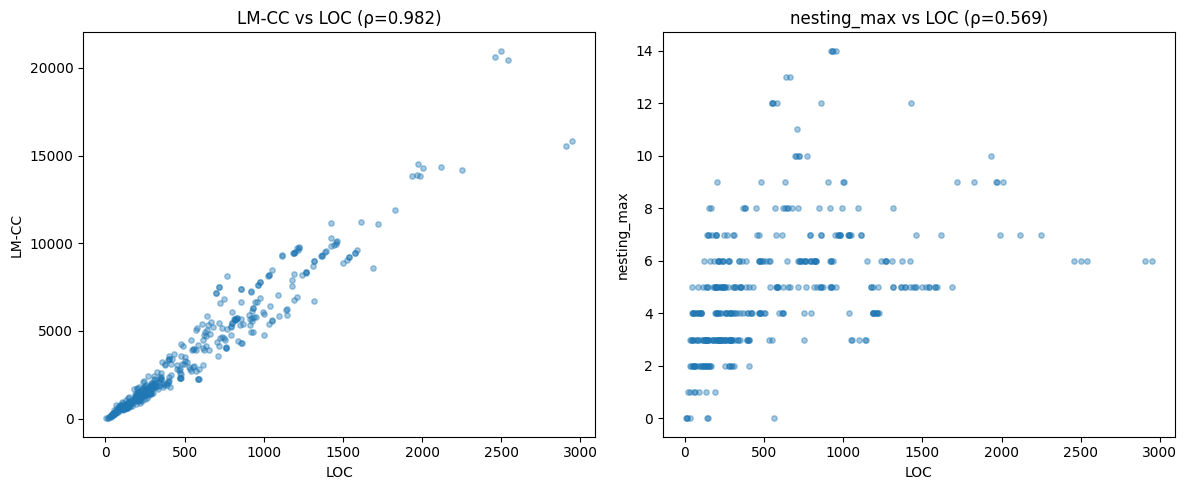

In [9]:
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

rho1, _ = spearmanr(clean["lm_cc_score"], clean["loc"])
axes[0].scatter(clean["loc"], clean["lm_cc_score"], alpha=0.4, s=15)
axes[0].set_xlabel("LOC"); axes[0].set_ylabel("LM-CC")
axes[0].set_title(f"LM-CC vs LOC (ρ={rho1:.3f})")

rho2, _ = spearmanr(clean["nesting_max"], clean["loc"])
axes[1].scatter(clean["loc"], clean["nesting_max"], alpha=0.4, s=15)
axes[1].set_xlabel("LOC"); axes[1].set_ylabel("nesting_max")
axes[1].set_title(f"nesting_max vs LOC (ρ={rho2:.3f})")

plt.tight_layout()
plt.savefig("collinearity.png", dpi=150)
plt.show()

## All verified agents — resolution rate & per-agent LM-CC

Beyond the single Agentless+Claude label above, the cells below load **all** verified
submissions (pinned revision), derive a per-task **resolution rate** (empirical difficulty),
and end with **Table 1**: one row per agent showing whether LM-CC correlates with that agent's
success. Row 1 (Agentless+Claude) reproduces the single-model result above.

In [10]:
# All-of-Verified: per-task resolution rate + long per-agent predictions
all_predictions = pd.read_parquet(PATHS.ALL_PREDICTIONS)   # [instance_id, model, resolved]
difficulty = pd.read_parquet(PATHS.TASK_DIFFICULTY)        # [instance_id, n_models, n_resolved, resolution_rate]

# attach the resolution rate to the clean per-task table (idempotent)
rate = difficulty.set_index("instance_id")
clean["resolution_rate"] = clean["instance_id"].map(rate["resolution_rate"])
clean["n_resolved"] = clean["instance_id"].map(rate["n_resolved"])
n_agents = int(rate["n_models"].iloc[0])

# long table for the per-agent analysis: predictions x metrics (clean tasks only)
metric_cols = ["lm_cc_score", "loc", "cc_sum", "halstead_volume", "nesting_max"]
long = all_predictions.merge(
    clean[["instance_id", *metric_cols]], on="instance_id", how="inner"
)
print(f"agents: {all_predictions['model'].nunique()}  |  clean tasks: {clean['instance_id'].nunique()}")
print(f"long rows: {len(long):,}  (agents x clean tasks)")
clean[["resolution_rate", "n_resolved"]].describe()

agents: 134  |  clean tasks: 404
long rows: 54,136  (agents x clean tasks)


,resolution_rate,n_resolved
count,404.000000,404.000000
mean,0.563747,75.542079
std,0.300712,40.295382
min,0.000000,0.000000
25%,0.341418,45.750000
50%,0.638060,85.500000
75%,0.820896,110.000000
max,0.962687,129.000000


count    404.000000
mean       0.563747
std        0.300712
min        0.000000
25%        0.341418
50%        0.638060
75%        0.820896
max        0.962687
Name: resolution_rate, dtype: float64


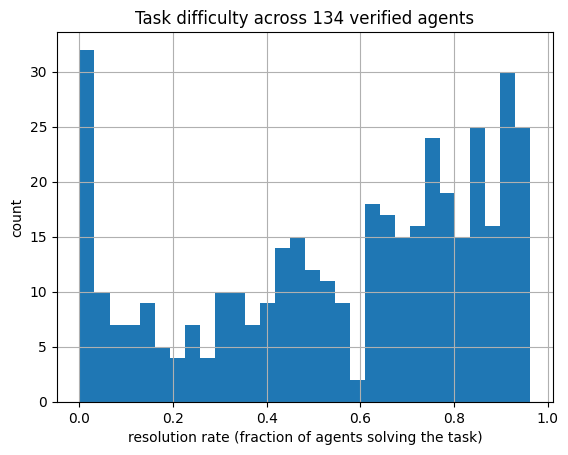

In [11]:
# Task-difficulty distribution across all verified agents
print(clean["resolution_rate"].describe())
clean["resolution_rate"].hist(bins=30)
plt.xlabel("resolution rate (fraction of agents solving the task)")
plt.ylabel("count")
plt.title(f"Task difficulty across {n_agents} verified agents")
plt.show()

In [12]:
# Complexity vs. continuous difficulty (resolution rate) - reuses full_correlation_table
rate_table = full_correlation_table(clean, available_metrics, score="resolution_rate", control="loc")
print("=== Full Correlation Table (vs. resolution_rate, all agents) ===")
print(rate_table.to_string(index=False))

=== Full Correlation Table (vs. resolution_rate, all agents) ===
             metric      sample_zero sample_partial_loc          subgroup_zero   subgroup_partial_loc
             cc_avg -0.065 (p=0.191)   -0.048 (p=0.333)  -0.517 (p=0.154, n=9)  -0.520 (p=0.198, n=9)
             cc_max -0.089 (p=0.072)   -0.004 (p=0.943) -0.518 (p=0.102, n=11)  -0.187 (p=0.672, n=9)
             cc_sum -0.134 (p=0.007)   +0.021 (p=0.674)  -0.617 (p=0.077, n=9) -0.000 (p=1.000, n=10)
    halstead_volume -0.128 (p=0.010)   +0.010 (p=0.840)  -0.850 (p=0.004, n=9) -0.000 (p=1.000, n=10)
halstead_difficulty -0.107 (p=0.032)   -0.003 (p=0.951) -0.582 (p=0.060, n=11) -0.373 (p=0.299, n=11)
    halstead_effort -0.129 (p=0.009)   +0.000 (p=0.995) -0.794 (p=0.006, n=10) -0.000 (p=1.000, n=10)
                loc -0.142 (p=0.004)                  — -0.648 (p=0.043, n=10)                      —
               lloc -0.141 (p=0.004)   +0.008 (p=0.871)  -0.783 (p=0.013, n=9) -0.000 (p=1.000, n=10)
        nesting_m

        count         mean  median
tier                              
hard       99  3949.339394  3141.4
medium    113  4290.189381  3140.2
easy      192  3558.914583  1893.1

Kruskal-Wallis across tiers: p = 0.041


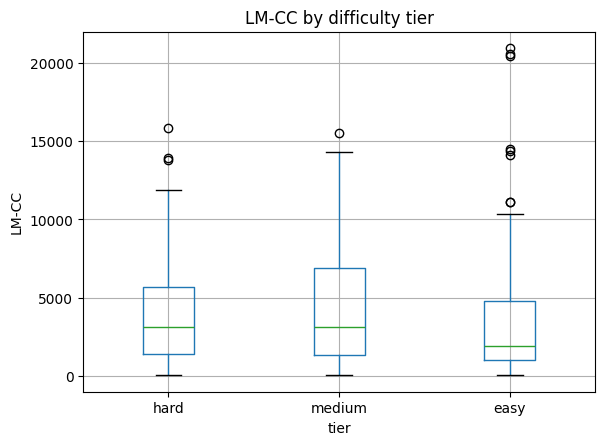

In [13]:
# LM-CC across difficulty tiers
from scipy.stats import kruskal

clean["tier"] = pd.cut(
    clean["resolution_rate"], bins=[-0.01, 0.33, 0.66, 1.01],
    labels=["hard", "medium", "easy"],
)
print(clean.groupby("tier", observed=True)["lm_cc_score"].agg(["count", "mean", "median"]))
groups = [g["lm_cc_score"].values for _, g in clean.groupby("tier", observed=True)]
print(f"\nKruskal-Wallis across tiers: p = {kruskal(*groups).pvalue:.3f}")

clean.boxplot(column="lm_cc_score", by="tier")
plt.suptitle("")
plt.title("LM-CC by difficulty tier")
plt.ylabel("LM-CC")
plt.show()

## Table 1 — LM-CC across all agents (the core question)

One row per agent: its resolve rate plus the four correlation flavours of LM-CC vs that
agent's `resolved`. Row 1 = Agentless+Claude, identical to the single-model result above.

In [14]:
from src.correlation import per_agent_correlation_table

table1 = per_agent_correlation_table(long, metric="lm_cc_score", score="resolved", control="loc")

def _short(name):
    # 20241202_agentless-1.5_claude-3.5-sonnet-20241022 -> agentless-1.5_claude-3.5-sonnet-20241022
    return name.split("_", 1)[1] if name[:8].isdigit() else name

show = table1.copy()
show["agent"] = show["agent"].map(_short)
show["resolve_rate"] = (show["resolve_rate"] * 100).round(1).astype(str) + " %"
for col in ["sample_zero", "sample_partial_loc", "subgroup_zero", "subgroup_partial_loc"]:
    show[col] = show[col].map(lambda v: f"{v:+.3f}")

print(f"Table 1 - LM-CC across all {len(table1)} verified agents")
print(show.to_string(index=False))

Table 1 - LM-CC across all 134 verified agents
                                                     agent resolve_rate sample_zero sample_partial_loc subgroup_zero subgroup_partial_loc
                    sonar-foundation-agent_claude-opus-4-5       84.7 %      +0.052             +0.040        +0.423               +0.000
                              livesweagent_claude-opus-4-5       84.2 %      -0.025             +0.045        -0.134               -0.000
                                     trae_doubao_seed_code       82.9 %      -0.021             +0.101        -0.055               -0.000
                                                    ACoder       82.9 %      -0.028             +0.034        -0.251               -0.000
                                 openhands_claude-opus-4-5       82.7 %      -0.029             +0.030        -0.361               -0.000
                                        atlassian-rovo-dev       81.9 %      -0.010             +0.102        -0.042         

In [15]:
# Top 10 agents where LM-CC best predicts failure: strongest (most negative) correlation.
# Rank by sample_zero (zero-order Spearman rho of LM-CC vs that agent's resolved).
ranking = table1.sort_values("sample_zero").head(10).copy()
ranking.insert(0, "rank", range(1, len(ranking) + 1))
ranking["agent"] = ranking["agent"].map(_short)
ranking["resolve_rate"] = (ranking["resolve_rate"] * 100).round(1).astype(str) + " %"
for col in ["sample_zero", "sample_partial_loc", "subgroup_zero", "subgroup_partial_loc"]:
    ranking[col] = ranking[col].map(lambda v: f"{v:+.3f}")

print("Top 10 agents by strongest negative LM-CC correlation (sample_zero)")
print(ranking.to_string(index=False))

Top 10 agents by strongest negative LM-CC correlation (sample_zero)
 rank                           agent resolve_rate sample_zero sample_partial_loc subgroup_zero subgroup_partial_loc
    1                 rag_claude3opus        8.4 %      -0.268             -0.034        -0.962               -0.000
    2            sweagent_claude3opus       17.8 %      -0.192             +0.039        -0.924               -0.000
    3                     rag_claude2        5.0 %      -0.182             +0.051        -0.838               -0.000
    4                   sweagent_gpt4       25.2 %      -0.180             +0.067        -0.824               -0.000
    5              appmap-navie_gpt4o       29.5 %      -0.173             +0.066        -0.798               -0.000
    6    sweagent_devstral_small_2507       42.3 %      -0.172             -0.044        -0.855               -0.000
    7                      nfactorial       55.2 %      -0.169             +0.049        -0.754               -0.